## Mid-Term Load Forecast — Alt Forecast Models EDA (Weather Zones, 2022 Feb - 2025 Dec)

Companion to `02_mtlf_eda.ipynb` (Actual/Selected/Error only). This notebook explores the
**7 alternate ERCOT forecast-model columns** (`A3, A6, E, E1, E2, E3, M`) parsed alongside
`Actual`/`Selected`, intended as a load-prediction feature (ensemble mean) rather than the
single-model error diagnostic. Per-model error and ensemble spread/error are deferred for now.

**Source:** `01_data/1.2_raw_api/mid_term_load_forecast_models_20220201_20251201.parquet`
- Raw source: `01_data/1.1_raw_bulk/Load Forcast/Mid_Term_Load_Forecast_Metrics_*.xlsx`
- Parsed by: `02_scripts/2_parsers/parse_mid_term_load_forecast_models_parquet.py`

**Schema**
- 8 ERCOT weather zones + system total (Coast, East, FarWest, NCent, North, SCent, South, West, ERCOT)
- Per zone: `actual, selected, a3, a6, e, e1, e2, e3, m` (9 zones x 9 cols + datetime = 82 cols)

**Output:** `01_data/2_cleaned/load/forecast/models/` (ERCOT zone only, for now — weather-zone
breakdown, per-model error, and ensemble spread/error deferred until needed)
- ensemble mean, ERCOT only: `model_ensemble_features_ERCOT_*.csv`
- ERCOT-only hourly table (actual + all models): `Hourly_ERCOT_all_models_*.csv`


In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

PARQUET = Path("../../01_data/1.2_raw_api/mid_term_load_forecast_models_20220201_20251201.parquet")
OUT_DIR = Path("../../01_data/2_cleaned/load/forecast/models")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
con = duckdb.connect()
# validate time range and column names

column_schema = con.execute(f"""
    DESCRIBE SELECT * FROM read_parquet('{PARQUET}')
""").df()
print('=== Schema ===')
print(column_schema.to_string(index=False))

time_range = con.execute(f"""
    SELECT
        MIN(datetime) AS min_date
        ,MAX(datetime) AS max_date
    FROM read_parquet('{PARQUET}')
""").fetchone()
print('\n=== Time Range ===')
print(f'{time_range[0]} to {time_range[1]}')

=== Schema ===
     column_name  column_type null  key default extra
        datetime TIMESTAMP_NS  YES None    None  None
    actual_Coast       DOUBLE  YES None    None  None
  selected_Coast       DOUBLE  YES None    None  None
        a3_Coast       DOUBLE  YES None    None  None
        a6_Coast       DOUBLE  YES None    None  None
         e_Coast       DOUBLE  YES None    None  None
        e1_Coast       DOUBLE  YES None    None  None
        e2_Coast       DOUBLE  YES None    None  None
        e3_Coast       DOUBLE  YES None    None  None
         m_Coast       DOUBLE  YES None    None  None
     actual_East       DOUBLE  YES None    None  None
   selected_East       DOUBLE  YES None    None  None
         a3_East       DOUBLE  YES None    None  None
         a6_East       DOUBLE  YES None    None  None
          e_East       DOUBLE  YES None    None  None
         e1_East       DOUBLE  YES None    None  None
         e2_East       DOUBLE  YES None    None  None
         e3_E

In [3]:
# load data
df = pd.read_parquet(PARQUET)
df.head(5)

,datetime,actual_Coast,selected_Coast,a3_Coast,a6_Coast,e_Coast,e1_Coast,e2_Coast,e3_Coast,m_Coast,...,m_West,actual_ERCOT,selected_ERCOT,a3_ERCOT,a6_ERCOT,e_ERCOT,e1_ERCOT,e2_ERCOT,e3_ERCOT,m_ERCOT
0,2022-02-01 01:00:00,9810.580078,9466.780273,9828.533203,9997.777344,9503.190430,9444.459961,9576.030273,9466.780273,9497.615234,...,967.532776,35709.832031,35148.0,36439.0,35843.0,34619.0,34616.0,35045.0,35148.0,34857.0
1,2022-02-01 02:00:00,9549.062500,9225.679688,9636.767578,9715.292969,9295.599609,9249.690430,9359.809570,9225.679688,9282.694336,...,937.474731,34733.136719,34054.0,35833.0,35123.0,33584.0,33475.0,33999.0,34054.0,33778.0
2,2022-02-01 03:00:00,9508.433594,9106.030273,9547.450195,9625.110352,9202.790039,9183.849609,9264.230469,9106.030273,9189.225586,...,901.666504,34448.484375,33502.0,35684.0,35008.0,33069.0,32889.0,33496.0,33502.0,33239.0
3,2022-02-01 04:00:00,9494.667969,9140.269531,9700.353516,9734.820312,9226.580078,9234.629883,9281.860352,9140.269531,9220.834961,...,915.193726,34471.617188,33634.0,36031.0,35248.0,33193.0,33033.0,33587.0,33634.0,33361.0
4,2022-02-01 05:00:00,9668.629883,9378.639648,9894.544922,9883.416992,9457.830078,9503.349609,9514.129883,9378.639648,9463.487305,...,955.033447,35127.335938,34556.0,36935.0,36172.0,34187.0,34051.0,34564.0,34556.0,34340.0


In [4]:
# EXPORT hourly ERCOT-only table (actual + selected + all 7 alt models)
ercot_cols = [c for c in df.columns if c.endswith('_ERCOT')]
df_ercot = df[['datetime'] + ercot_cols]
df_ercot.to_csv(OUT_DIR/'Hourly_ERCOT_all_models_20220201_20251201.csv', index=False)
df_ercot.head(3)

,datetime,actual_ERCOT,selected_ERCOT,a3_ERCOT,a6_ERCOT,e_ERCOT,e1_ERCOT,e2_ERCOT,e3_ERCOT,m_ERCOT
0,2022-02-01 01:00:00,35709.832031,35148.0,36439.0,35843.0,34619.0,34616.0,35045.0,35148.0,34857.0
1,2022-02-01 02:00:00,34733.136719,34054.0,35833.0,35123.0,33584.0,33475.0,33999.0,34054.0,33778.0
2,2022-02-01 03:00:00,34448.484375,33502.0,35684.0,35008.0,33069.0,32889.0,33496.0,33502.0,33239.0


In [5]:
# -- Null count by month --
df_missing = df[df.isna().any(axis=1)].copy()
df_missing['month'] = df_missing['datetime'].dt.strftime('%Y-%m')
print('=== Missing rows by month (ERCOT cols only, for readability) ===')
df_missing.groupby('month')[ercot_cols].count().reset_index()

=== Missing rows by month (ERCOT cols only, for readability) ===


,month,actual_ERCOT,selected_ERCOT,a3_ERCOT,a6_ERCOT,e_ERCOT,e1_ERCOT,e2_ERCOT,e3_ERCOT,m_ERCOT
0,2022-03,23,23,23,23,23,23,23,23,23
1,2022-04,1,1,1,1,1,1,1,1,1
2,2022-05,0,0,0,0,0,0,0,0,0
3,2022-06,0,0,0,0,0,0,0,0,0
4,2023-02,0,0,0,0,0,0,0,0,0
5,2023-03,0,0,0,0,0,0,0,0,0
6,2023-04,0,0,0,0,0,0,0,0,0
7,2023-05,23,23,23,23,23,23,23,23,23
8,2023-06,1,1,1,1,1,1,1,1,1
9,2023-11,0,0,0,0,0,0,0,0,0


In [6]:
# -- duplicate datetimes --
n_dup = df['datetime'].duplicated().sum()
print(f'Duplicate datetime rows: {n_dup}')
# Same known artifact as parse_mid_term_load_forecast_parquet.py's output (03,e2_mtlf_eda.ipynb also finds
# 103): intra-file sheet-length mismatch where one sheet has a timestamp the others don't,
# leaving a near-empty row from the outer merge. See mid-term-load-forecast.md.

Duplicate datetime rows: 103


In [7]:
# -- Ensemble features (mean across the 7 alt models, excludes 'selected') --
MODELS = ['selected', 'a3', 'a6', 'e', 'e1', 'e2', 'e3', 'm']
ZONES = ['Coast', 'East', 'FarWest', 'NCent', 'North', 'SCent', 'South', 'West', 'ERCOT']
ALT_MODELS = ['a3', 'a6', 'e', 'e1', 'e2', 'e3', 'm']
for zone in ZONES:
    alt_cols = [f'{m}_{zone}' for m in ALT_MODELS]
    df[f'ensemble_mean_{zone}'] = df[alt_cols].mean(axis=1)

df[['datetime', 'actual_ERCOT', 'selected_ERCOT', 'ensemble_mean_ERCOT']].describe().round(1)

,datetime,actual_ERCOT,selected_ERCOT,ensemble_mean_ERCOT
count,33676,33622.0,33622.0,33622.0
mean,2023-12-31 06:26:13.155956736,52560.8,52656.6,52366.1
min,2022-02-01 01:00:00,31955.1,30412.0,30965.6
25%,2023-01-15 19:45:00,44150.0,44269.0,44026.4
50%,2023-12-30 10:30:00,49910.1,49937.5,49669.2
75%,2024-12-15 04:15:00,59325.7,59451.8,59104.1
max,2025-12-01 00:00:00,85559.0,87055.0,87179.3
std,NaN,11191.0,11414.5,11250.4


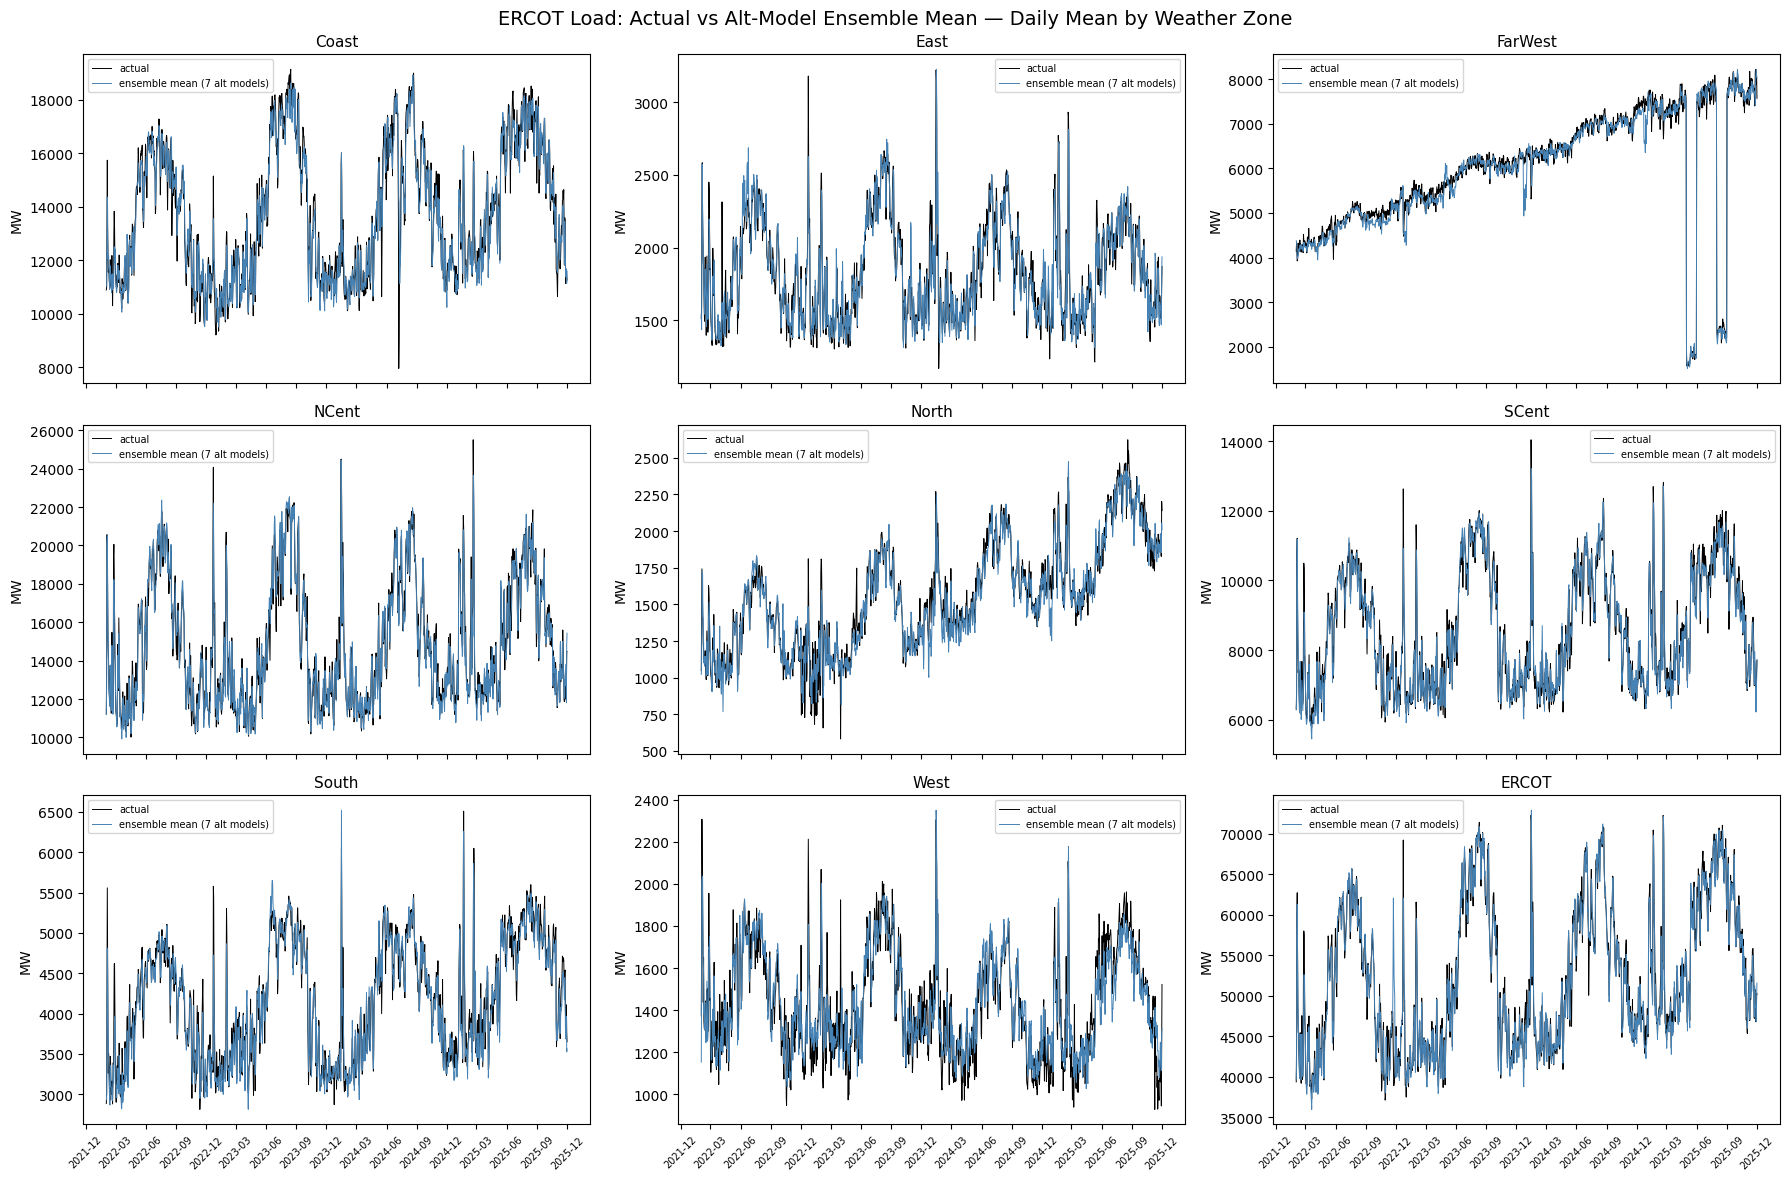

In [8]:
# -- Daily mean time series: actual vs ensemble mean, by weather zone --
df['date'] = pd.to_datetime(df['datetime']).dt.date
daily = df.groupby('date')[[f'actual_{z}' for z in ZONES] + [f'ensemble_mean_{z}' for z in ZONES]].mean()

fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharex=True)
axes = axes.flatten()

for ax, zone in zip(axes, ZONES):
    ax.plot(daily.index, daily[f'actual_{zone}'], lw=0.7, color='black', label='actual')
    ax.plot(daily.index, daily[f'ensemble_mean_{zone}'], lw=0.7, color='steelblue', label='ensemble mean (7 alt models)')
    ax.set_title(zone, fontsize=11)
    ax.set_ylabel('MW')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.legend(fontsize=7)

plt.suptitle('ERCOT Load: Actual vs Alt-Model Ensemble Mean — Daily Mean by Weather Zone', fontsize=14)
plt.tight_layout()
plt.savefig(OUT_DIR/'actual_vs_ensemble_mean_weather_zone_20220201_20251201.png')
plt.show()

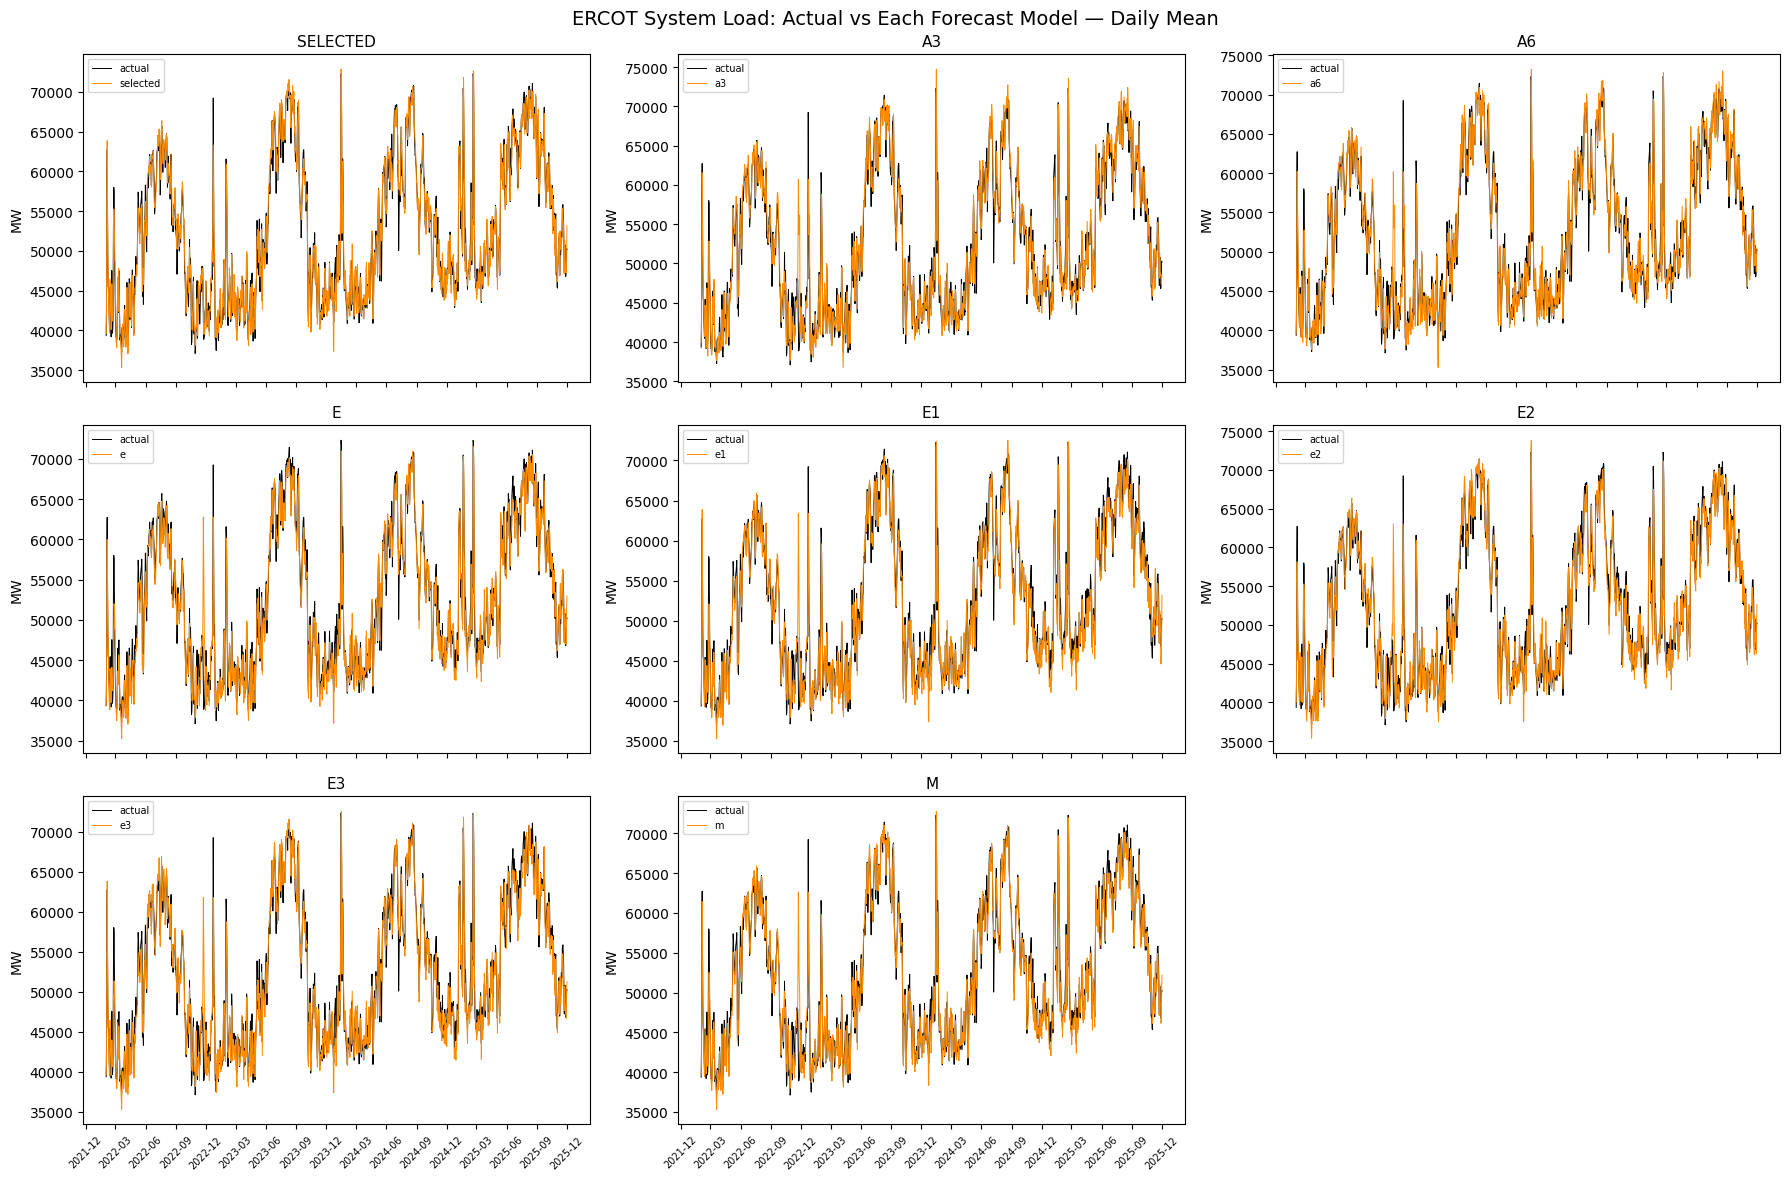

In [9]:
# -- Daily mean time series: all 7 alt models + selected, ERCOT zone only --
model_cols_ercot = [f'{m}_ERCOT' for m in MODELS]
daily_models = df.groupby('date')[model_cols_ercot + ['actual_ERCOT']].mean()

fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharex=True)
axes = axes.flatten()

for ax, model in zip(axes, MODELS):
    col = f'{model}_ERCOT'
    ax.plot(daily_models.index, daily_models['actual_ERCOT'], lw=0.7, color='black', label='actual')
    ax.plot(daily_models.index, daily_models[col], lw=0.7, color='darkorange', label=model)
    ax.set_title(model.upper(), fontsize=11)
    ax.set_ylabel('MW')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.legend(fontsize=7)

axes[-1].axis('off')
plt.suptitle('ERCOT System Load: Actual vs Each Forecast Model — Daily Mean', fontsize=14)
plt.tight_layout()
plt.savefig(OUT_DIR/'actual_vs_each_model_ERCOT_20220201_20251201.png')
plt.show()

In [10]:
# -- Validation: sum(8 zones) vs ERCOT total, for 'selected' and ensemble mean --
zone8 = [z for z in ZONES if z != 'ERCOT']

for label, prefix in [('selected', 'selected'), ('ensemble_mean', 'ensemble_mean')]:
    cols8 = [f'{prefix}_{z}' for z in zone8]
    total_col = f'{prefix}_ERCOT'
    df_val = df.dropna(subset=cols8 + [total_col]).copy()
    df_val['zone_sum'] = df_val[cols8].sum(axis=1)
    df_val['diff'] = (df_val['zone_sum'] - df_val[total_col]).abs()
    print(f'--- {label} ---')
    print(f'Rows with all 8 zones + ERCOT total non-null: {len(df_val)}')
    print(f'Max |sum(zones) - ercot_total| : {df_val["diff"].max():.2f} MW')
    print(f'Mean |diff|                    : {df_val["diff"].mean():.4f} MW')
    print()

--- selected ---
Rows with all 8 zones + ERCOT total non-null: 33573
Max |sum(zones) - ercot_total| : 6790.17 MW
Mean |diff|                    : 252.9262 MW

--- ensemble_mean ---
Rows with all 8 zones + ERCOT total non-null: 33573
Max |sum(zones) - ercot_total| : 24024.51 MW
Mean |diff|                    : 358.9632 MW



In [11]:
# -- export (ERCOT only, for now) -----------------------------------------

# ensemble mean, ERCOT only (per-model error and spread/std excluded for now)
df_ensemble = df[['datetime', 'ensemble_mean_ERCOT']]
df_ensemble.to_csv(OUT_DIR/'model_ensemble_features_ERCOT_20220201_20251201.csv', index=False)

print('Wrote:')
for f in sorted(OUT_DIR.glob('*')):
    print(' -', f.name)

Wrote:
 - Hourly_ERCOT_all_models_20220201_20251201.csv
 - actual_vs_each_model_ERCOT_20220201_20251201.png
 - actual_vs_ensemble_mean_weather_zone_20220201_20251201.png
 - model_ensemble_features_ERCOT_20220201_20251201.csv
 - model_error_ERCOT_20220201_20251201.csv
